In [ ]:
suppressPackageStartupMessages(library(magrittr))
library(ggplot2)
library(patchwork)
library(prismatic)
library(paletteer)
library(data.table)
# library(rlang)
library(GetoptLong)
library(logger)


In [3]:
basedir <- "/home/liuc9/github/scMOCHA-data/data"
foundation_out <- file.path(basedir, "scfoundation/out")
gse_dataset_scfoundation <- readxl::read_excel(file.path(foundation_out, "gses_cell_ratio_variant_meta.xlsx")) |>
  dplyr::filter(gseid != "WT")
gse_dataset_scfoundation2 <- readxl::read_excel(
  "/home/liuc9/github/scMOCHA-data/data/scfoundation2/PBMC/out/gses_cell_ratio_variant_meta.xlsx"
)

gse_dataset <- dplyr::bind_rows(gse_dataset_scfoundation, gse_dataset_scfoundation2)

gseids <- c(
  "GSE155673",
  "GSE157344",
  "GSE149689",
  "GSE171555",
  "GSE155223",
  "GSE163668",
  "GSE175524",
  "GSE206283",
  "GSE226598",
  "GSE261140",
  "GSE279945",
  "GSE214865",
  # "GSE220189",
  "GSE233844",
  "GSE175499",
  "GSE149313",
  "GSE154386",
  "GSE159117",
  "GSE188632",
  "GSE166992",
  "GSE162117",
  "GSE226602",
  "GSE161354",
  "GSE235050",
  "GSE181279",
  # scfoundation2
  "GSE143353",
  "GSE148215",
  "GSE163314",
  "GSE163633",
  "GSE164690",
  "GSE167825",
  "GSE174125",
  "GSE184703",
  "GSE153421",
  "GSE147794",
  "GSE168453"
)


In [4]:
gse_dataset |>
  dplyr::select(gseid, srrid)

gse_dataset |>
  dplyr::select(gseid) |>
  dplyr::distinct() |>
  dplyr::mutate(
    biosample = purrr::map(
      .x = gseid,
      .f = \(.gseid) {
        .filename <- file.path(basedir, .gseid, "{.gseid}.edirect.biosample.csv" |> glue::glue())
        .d <- data.table::fread(.filename)
        data.table::fread(
          file.path(
            basedir,
            .gseid,
            "{.gseid}.SraRunTable" |> glue::glue()
          ),
          sep = ","
        ) |>
          dplyr::select(
            biosample_id = BioSample,
            srrid = SampleName,
            Experiment,
            Sample
          ) |>
          dplyr::distinct() ->
        .dd
        log_success(
          file.exists(
            file.path(
              basedir,
              .gseid,
              "{.gseid}.SraRunTable.GSM" |> glue::glue()
            )
          )
        )
        data.table::fread(
          file.path(
            basedir,
            .gseid,
            "{.gseid}.SraRunTable.GSM" |> glue::glue()
          ),
          sep = ","
        ) |>
          dplyr::select(
            experiment_name,
            Experiment = experiment_accession
          ) |>
          dplyr::distinct() ->
        .dd_gsm
        .dd |> dplyr::inner_join(.dd_gsm, by = "Experiment") ->
        .dd_gsm_d
        .d |>
          dplyr::inner_join(
            .dd_gsm_d,
            by = c("biosample_id" = "biosample_id")
          ) ->
        .ddd

        tibble::tibble(
          biosample = list(.ddd),
          colnames = list(colnames(.ddd))
        )
      }
    )
  ) |>
  tidyr::unnest(cols = biosample) ->
gse_dataset_load


gseid,srrid
<chr>,<chr>
GSE155673,GSM4712885
GSE155673,GSM4712899
GSE155673,GSM4712901
GSE155673,GSM4712903
GSE155673,GSM4712893
GSE155673,GSM4712895
GSE155673,GSM4712887
GSE155673,GSM4712889
GSE157344,GSM4762161


In [5]:
gse_dataset_load$colnames |>
  purrr::reduce(intersect) ->
sel_colnames

c_colnames <- c(
  "geo_id",
  "tissue",
  "age",
  "sex",
  "race",
  "ethnicity",
  "genotype",
  "source_name",
  "cell_type",
  "disease",
  "disease_severity",
  "disease_group",
  "treatment",
  "clinic_status",
  "subject_group",
  "subject_status",
  "diagnosis",
  "covid_status",
  "exposure",
  "condition"
)

gse_dataset_load |>
  dplyr::mutate(
    biosample_sel = purrr::map(
      .x = biosample,
      .f = \(.biosample) {
        .coln <- c(sel_colnames, c_colnames)
        # Add missing columns directly to .biosample
        for (.colname in setdiff(.coln, colnames(.biosample))) {
          .biosample[[.colname]] <- NA_character_
        }
        # Select the columns from the modified data frame
        .biosample |>
          dplyr::select(dplyr::all_of(.coln)) |>
          dplyr::mutate(age = as.character(age)) ->
        .out
      }
    )
  ) |>
  dplyr::select(gseid, biosample_sel) ->
gse_dataset_load_sel

gse_dataset_load_sel |>
  tidyr::unnest(cols = biosample_sel) ->
gse_dataset_load_sel_unnest



gse_dataset_load_sel_unnest |>
  dplyr::mutate(
    srrid = experiment_name
  ) |>
  dplyr::relocate(srrid, .before = 1) |>
  dplyr::select(
    dplyr::all_of(c("gseid", "srrid", c_colnames))
  ) |>
  dplyr::filter(
    srrid %in% gse_dataset$srrid
  ) ->
gse_dataset_load_sel_unnest_age_meta


In [6]:
# race --------------------------------------------------------------------
gse_dataset_load_sel_unnest_age_meta |>
  dplyr::select(gseid, srrid, race) |>
  dplyr::rename(
    Race = race
  ) |>
  dplyr::mutate(
    Race = ifelse(is.na(Race), "Unknown", Race)
  ) |>
  dplyr::mutate(
    Race = stringr::str_to_title(Race)
  ) |>
  dplyr::mutate(
    Race = factor(Race, levels = c("White", "Black", "Hispanic", "Unknown"))
  ) ->
gse_dataset_race

# ethnicity ----------------------------------------------------------------
gse_dataset_load_sel_unnest_age_meta |>
  dplyr::select(gseid, srrid, ethnicity) |>
  dplyr::rename(
    Ethnicity = ethnicity
  ) |>
  dplyr::mutate(
    Ethnicity = ifelse(is.na(Ethnicity), "Unknown", Ethnicity)
  ) |>
  dplyr::mutate(
    Ethnicity = stringr::str_to_title(Ethnicity)
  ) |>
  dplyr::mutate(
    Ethnicity = factor(Ethnicity, levels = c("Caucasian", "Hispanic Or Latino", "Not Hispanic Or Latino", "Unknown"))
  ) ->
gse_dataset_ethnicity

# gender ------------------------------------------------------------------
gse_dataset_load_sel_unnest_age_meta |>
  dplyr::select(gseid, srrid, sex) |>
  dplyr::rename(
    Gender = sex
  ) |>
  dplyr::mutate(
    Gender = ifelse(is.na(Gender), "Unknown", Gender)
  ) |>
  dplyr::mutate(
    Gender = stringr::str_to_title(Gender)
  ) |>
  dplyr::mutate(
    Gender = factor(Gender, levels = c("Male", "Female", "Unknown"))
  ) ->
gse_dataset_gender

# age ---------------------------------------------------------------------
gse_dataset_load_sel_unnest_age_meta |>
  dplyr::select(gseid, srrid, age) |>
  dplyr::rename(
    Age = age
  ) |>
  dplyr::mutate(
    Age = gsub("y|yo|years old| ", "", Age)
  ) |>
  dplyr::mutate(
    Age = gsub("&gt;", ">", Age)
  ) |>
  dplyr::mutate(
    Age = gsub("&lt;", "<", Age)
  ) |>
  dplyr::mutate(
    Age = ifelse(Age %in% c("Fetal(28-29weeks)", "Neonate(39-41weeks)"), "<1", Age)
  ) |>
  dplyr::mutate(
    Age_new = as.integer(Age)
  ) |>
  dplyr::mutate(
    Age_group = purrr::map_chr(
      .x = Age,
      .f = \(.Age) {
        .x <- as.integer(.Age)
        if (is.na(.x)) {
          return(.x)
        }
        if (.x < 1) {
          return("<1")
        } else if (.x >= 1 && .x <= 5) {
          return("1~5")
        } else {
          # For ages > 5
          lower <- 5 * floor(.x / 5)
          upper <- lower + 5
          return(paste0(lower, "~", upper))
        }
      }
    )
  ) |>
  dplyr::mutate(
    Age_group = ifelse(is.na(Age_group), "Unknown", Age_group)
  ) |>
  dplyr::mutate(
    Age_group = factor(Age_group, levels = c(
      "<1", "1~5", "5~10", "10~15", "15~20",
      "20~25", "25~30", "30~35", "35~40", "40~45",
      "45~50", "50~55", "55~60", "60~65", "65~70",
      "70~75", "75~80", "80~85", "85~90", "90~95",
      "95~100", "Unknown"
    ))
  ) ->
gse_dataset_age

# disease status ------------------------------------------------------------
gse_dataset_disease_status_ <- data.table::fread(
  file.path(foundation_out, "metadata_disease_mess_for_claude.out.csv")
)



gse_dataset_load_sel_unnest_age_meta |>
  dplyr::select(gseid, srrid) |>
  dplyr::left_join(
    gse_dataset_disease_status_,
    by = c("gseid", "srrid")
  ) |>
  dplyr::rename(
    disease = disease_,
    status = status_
  ) |>
  dplyr::mutate(
    status = ifelse(is.na(status), "Unknown", status),
    disease = ifelse(is.na(disease), "Unknown", disease)
  ) ->
gse_dataset_disease_status


Warning message:
“There was 1 warning in `dplyr::mutate()`.
ℹ In argument: `Age_new = as.integer(Age)`.
Caused by warning:
! NAs introduced by coercion”
Warning message:
“There were 15 warnings in `dplyr::mutate()`.
The first warning was:
ℹ In argument: `Age_group = purrr::map_chr(...)`.
Caused by warning in `.f()`:
! NAs introduced by coercion
ℹ Run `dplyr::last_dplyr_warnings()` to see the 14 remaining warnings.”


In [7]:
gse_dataset_metadata_full <- readr::read_rds(
  file.path(foundation_out, "gse_dataset_metadata_full.rds")
)


In [8]:
fn_eda <- function(anno_meta_info_clean) {
  p_ncells <- tryCatch(
    expr = {
      anno_meta_info_clean |>
        ggstatsplot::ggscatterstats(
          x = "# cells after filter",
          y = "# of somatic variants",
          title = "Number of Cells",
          xlab = "",
          ylab = "Number of Somatic Variants",
        )
    },
    error = function(e) {
      log_fatal("Error in plotting p_ncells: ", e)
      ggplot()
    }
  )

  p_numi <- tryCatch(
    expr = {
      anno_meta_info_clean |>
        ggstatsplot::ggscatterstats(
          x = "Median UMI/cell",
          y = "# of somatic variants",
          title = "Number of UMI",
          xlab = "",
          ylab = "Number of Somatic Variants",
        )
    },
    error = function(e) {
      log_fatal("Error in plotting p_numi: ", e)
      ggplot()
    }
  )

  p_avg_depth <- tryCatch(
    expr = {
      anno_meta_info_clean |>
        ggstatsplot::ggscatterstats(
          x = "Depth read mean",
          y = "# of somatic variants",
          title = "Average Depth",
          xlab = "",
          ylab = "Number of Somatic Variants",
        )
    },
    error = function(e) {
      log_fatal("Error in plotting p_avg_depth: ", e)
      ggplot()
    }
  )

  p_age <- tryCatch(
    expr = {
      anno_meta_info_clean |>
        ggstatsplot::ggscatterstats(
          x = "Age_new",
          y = "# of somatic variants",
          title = "Age",
          xlab = "",
          ylab = "Number of Somatic Variants",
        )
    },
    error = function(e) {
      log_fatal("Error in plotting p_age: ", e)
      ggplot()
    }
  )

  p_gender <- tryCatch(
    expr = {
      anno_meta_info_clean |>
        ggstatsplot::ggbetweenstats(
          x = Gender,
          y = "# of somatic variants",
          xlab = "",
          ylab = "Number of Somatic Variants",
          title = "Gender",
        )
    },
    error = function(e) {
      log_fatal("Error in plotting p_gender: ", e)
      ggplot()
    }
  )

  p_disease <- tryCatch(
    expr = {
      anno_meta_info_clean |>
        ggstatsplot::ggbetweenstats(
          x = disease,
          y = "# of somatic variants",
          xlab = "",
          ylab = "Number of Somatic Variants",
          title = "Disease"
        )
    },
    error = function(e) {
      log_fatal("Error in plotting p_disease: ", e)
      ggplot()
    }
  )

  wrap_plots(list(p_ncells, p_numi, p_avg_depth, p_age, p_gender, p_disease), ncol = 3) -> p_combined
  p_combined
}


Number of labels is greater than default palette color count.
• Select another color `palette` (and/or `package`).
`stat_xsidebin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_ysidebin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_xsidebin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_ysidebin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_xsidebin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_ysidebin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_xsidebin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_ysidebin()` using `bins = 30`. Pick better value with `binwidth`.
Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”
Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”

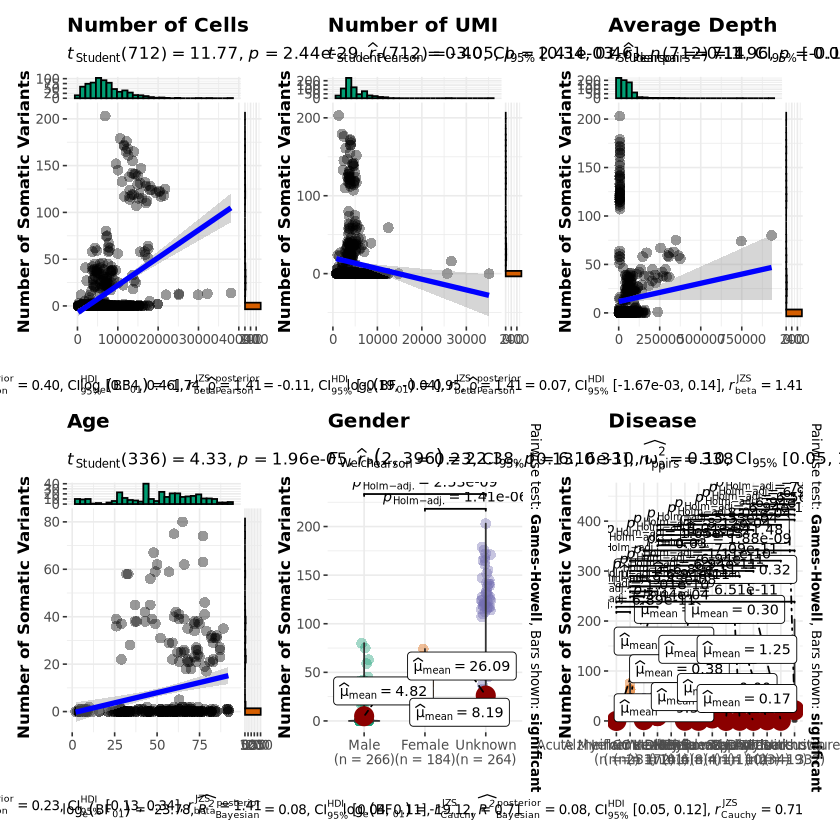

In [10]:
fn_eda(gse_dataset_metadata_full)
